In [2]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats

In [3]:
# Carga los archivos de datos en diferentes DataFrames
df_calls = pd.read_csv('datasets/megaline_calls.csv')
df_internet = pd.read_csv('datasets/megaline_internet.csv')
df_messages = pd.read_csv('datasets/megaline_messages.csv')
df_plans = pd.read_csv('datasets/megaline_plans.csv')
df_users = pd.read_csv('datasets/megaline_users.csv')

# Plans (Tarifas)

In [4]:
df_plans.info()
df_plans.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Análisis (plans)

# Users (Usuarios/as)

In [5]:
df_users.info()
df_users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


## Análisis (users)

churn_date

In [6]:
df_users.isna().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

In [7]:
df_users[~df_users['churn_date'].isna()]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
12,1012,Jonelle,Mcbride,59,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-06-28,surf,2018-11-16
22,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07
40,1040,Paris,Santos,72,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-12-23,surf,2018-12-30
50,1050,Jone,Owen,23,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-03-20,ultimate,2018-10-07
54,1054,Denis,Frost,50,"Phoenix-Mesa-Chandler, AZ MSA",2018-04-21,surf,2018-12-31
67,1067,Robt,Allen,37,"Grand Rapids-Kentwood, MI MSA",2018-09-24,surf,2018-11-24
83,1083,Lyndia,Acevedo,65,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-10-26,surf,2018-12-18
84,1084,Wiley,Mckinney,21,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-06-04,surf,2018-11-11
94,1094,Walter,Petersen,54,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-10-30,surf,2018-12-12


# Llamadas (calls)

In [8]:
df_calls.info()
df_calls.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


## Análisis (calls)

No tiene nulos
No tiene duplicados

In [9]:
df_calls.duplicated().sum()

np.int64(0)

In [10]:
# Convert data type of call_date to datetime
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [11]:
# Month extract
df_calls['month'] = df_calls['call_date'].dt.month
print(df_calls)

              id  user_id  call_date  duration  month
0        1000_93     1000 2018-12-27      8.52     12
1       1000_145     1000 2018-12-27     13.66     12
2       1000_247     1000 2018-12-27     14.48     12
3       1000_309     1000 2018-12-28      5.76     12
4       1000_380     1000 2018-12-30      4.22     12
...          ...      ...        ...       ...    ...
137730  1499_199     1499 2018-11-21      8.72     11
137731  1499_200     1499 2018-10-20     10.89     10
137732  1499_201     1499 2018-09-21      8.12      9
137733  1499_202     1499 2018-10-10      0.37     10
137734  1499_203     1499 2018-12-29     13.86     12

[137735 rows x 5 columns]


In [12]:

# Pivot table of calls dataframe
metrics_calls = df_calls.pivot_table(index=['user_id', 'month'], values='duration', aggfunc=['sum', 'count']).reset_index()
metrics_calls.columns = ['user_id', 'month', 'total_minute_duration', 'total_calls_count']
metrics_calls

,user_id,month,total_minute_duration,total_calls_count
0,1000,12,116.83,16
1,1001,8,171.14,27
2,1001,9,297.69,49
3,1001,10,374.11,65
4,1001,11,404.59,64
...,...,...,...,...
2253,1498,12,324.77,39
2254,1499,9,330.37,41
2255,1499,10,363.28,53
2256,1499,11,288.56,45


In [13]:
# Create function to calculate the cost of calls for each user, based on the plan they have
# Round according the comments
def minute_round(row):
    return math.ceil(row)

In [14]:
metrics_calls['total_round_minutes'] = metrics_calls['total_minute_duration'].apply(minute_round)
metrics_calls

,user_id,month,total_minute_duration,total_calls_count,total_round_minutes
0,1000,12,116.83,16,117
1,1001,8,171.14,27,172
2,1001,9,297.69,49,298
3,1001,10,374.11,65,375
4,1001,11,404.59,64,405
...,...,...,...,...,...
2253,1498,12,324.77,39,325
2254,1499,9,330.37,41,331
2255,1499,10,363.28,53,364
2256,1499,11,288.56,45,289


In [15]:
# Merge with users DataFrame to get the plan column
metrics_calls = metrics_calls.merge(df_users, on='user_id', how='inner')
metrics_calls

,user_id,month,total_minute_duration,total_calls_count,total_round_minutes,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,12,116.83,16,117,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,8,171.14,27,172,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1001,9,297.69,49,298,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
3,1001,10,374.11,65,375,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
4,1001,11,404.59,64,405,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2253,1498,12,324.77,39,325,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN
2254,1499,9,330.37,41,331,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN
2255,1499,10,363.28,53,364,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN
2256,1499,11,288.56,45,289,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN


In [16]:
# Only we use the plan column
metrics_calls = metrics_calls.loc[:, ['user_id', 'month', 'total_round_minutes', 'total_calls_count', 'plan']]
metrics_calls

,user_id,month,total_round_minutes,total_calls_count,plan
0,1000,12,117,16,ultimate
1,1001,8,172,27,surf
2,1001,9,298,49,surf
3,1001,10,375,65,surf
4,1001,11,405,64,surf
...,...,...,...,...,...
2253,1498,12,325,39,surf
2254,1499,9,331,41,surf
2255,1499,10,364,53,surf
2256,1499,11,289,45,surf


In [17]:
# Function to calculate the total payment of calls regarding the plan type
def pay_calls(row):
    max_minutes = 0
    extra_cost = 1
    payment_default = 0 #Excedente

    if row['plan'] == 'surf':
        max_minutes = 500
        extra_cost = 0.03
        payment_default = 20
    else:
        max_minutes = 3000
        extra_cost = 0.01
        payment_default = 70

    if row['total_round_minutes'] > max_minutes:
        payment_default += (row['total_round_minutes'] - max_minutes) * extra_cost

    return payment_default

In [18]:
metrics_calls['payment'] = metrics_calls.apply(pay_calls, axis=1)
metrics_calls

,user_id,month,total_round_minutes,total_calls_count,plan,payment
0,1000,12,117,16,ultimate,70.0
1,1001,8,172,27,surf,20.0
2,1001,9,298,49,surf,20.0
3,1001,10,375,65,surf,20.0
4,1001,11,405,64,surf,20.0
...,...,...,...,...,...,...
2253,1498,12,325,39,surf,20.0
2254,1499,9,331,41,surf,20.0
2255,1499,10,364,53,surf,20.0
2256,1499,11,289,45,surf,20.0


In [19]:
# Analizando llamadas
# se exceden un poco los surf, pero ultimate no se pasa
# surf es un poco más rentable
metrics_calls.groupby('plan')['payment'].mean()

plan
surf        21.495864
ultimate    70.000000
Name: payment, dtype: float64

In [20]:
# Analizando la cantidad de ganancia obtenida
metrics_calls.groupby('plan')['payment'].sum()

plan
surf        33211.11
ultimate    49910.00
Name: payment, dtype: float64

In [21]:
# Hipotesis nula (el chisme):
# Crear primero H1, que es la hipotesis alternativa (lo que yo creo que está pasando) y la H0 es lo contrario
#H0: El promedio de pago de los de surf es <= ultimate
#H1: El promedio de pago de los surf > ultimate
# NOTA: En general queremos que H0 sea rechazada, para que la H1 sea la correcta. De ahí el porque H0 es la hipotesis nula, para
# que H1 quede como la hipotesis alternativa y aceptada

# Crear un t-test (t-student): Probar promedios de diferentes grupos de datos
# muestra:
# poblacion:

confident_level = 0.95 # Que tan confiado quiero estar en mi prueba estadistica
alpha = 1 - confident_level #

# comprobar promedios, grupos independientes, si es surf no puede ser de ultimate
surf_group = metrics_calls.query('plan == "surf"')['payment']
ultimate_group = metrics_calls.query('plan == "ultimate"')['payment']
result = stats.ttest_ind(surf_group, ultimate_group, equal_var=False)

# Varianza: que tan dispersos están mis datos con respecto del promedio




/Users/drbiggorila/Library/Caches/pypoetry/virtualenvs/tripleten-dBYMD7ZO-py3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [22]:
# pvalue: Valor de probabilidad
if result.pvalue < alpha:
    print('Rechazamos la hipotesis nula')
# Los datos son muy parecidos

# hay que saber cual es más rentable para la empresa
# sesion del 17 de marzo

Rechazamos la hipotesis nula


# Mensajes (messages)

In [23]:
df_messages.info()
df_messages.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


## Análisis (messages)

In [24]:
df_messages.duplicated().sum()

np.int64(0)

In [25]:
df_messages.isna().sum()

id              0
user_id         0
message_date    0
dtype: int64

In [26]:
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


In [27]:
df_messages['month'] = df_messages['message_date'].dt.month
df_messages

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12
...,...,...,...,...
76046,1497_526,1497,2018-12-24,12
76047,1497_536,1497,2018-12-24,12
76048,1497_547,1497,2018-12-31,12
76049,1497_558,1497,2018-12-24,12


In [28]:
metrics_messages = df_messages.pivot_table(index=['user_id', 'month'], values='id', aggfunc='count')
metrics_messages.columns = ['total_messages']
metrics_messages.reset_index(inplace=True)
metrics_messages

,user_id,month,total_messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [29]:
metrics_calls

,user_id,month,total_round_minutes,total_calls_count,plan,payment
0,1000,12,117,16,ultimate,70.0
1,1001,8,172,27,surf,20.0
2,1001,9,298,49,surf,20.0
3,1001,10,375,65,surf,20.0
4,1001,11,405,64,surf,20.0
...,...,...,...,...,...,...
2253,1498,12,325,39,surf,20.0
2254,1499,9,331,41,surf,20.0
2255,1499,10,364,53,surf,20.0
2256,1499,11,289,45,surf,20.0


In [30]:
metrics_calls.drop(['plan', 'payment'], axis=1, inplace=True)
metrics_calls

,user_id,month,total_round_minutes,total_calls_count
0,1000,12,117,16
1,1001,8,172,27
2,1001,9,298,49
3,1001,10,375,65
4,1001,11,405,64
...,...,...,...,...
2253,1498,12,325,39
2254,1499,9,331,41
2255,1499,10,364,53
2256,1499,11,289,45


# Accumulated

In [31]:
accumulated = metrics_calls.merge(metrics_messages, how='outer', on=['user_id', 'month'])
# inner: Sólo une por las coincidencias de user_id &(and) month
# outer: Une por las coincidencias de user_id |(or) month
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages
0,1000,12,117.0,16.0,11.0
1,1001,8,172.0,27.0,30.0
2,1001,9,298.0,49.0,44.0
3,1001,10,375.0,65.0,53.0
4,1001,11,405.0,64.0,36.0
...,...,...,...,...,...
2286,1498,12,325.0,39.0,NaN
2287,1499,9,331.0,41.0,NaN
2288,1499,10,364.0,53.0,NaN
2289,1499,11,289.0,45.0,NaN


In [32]:
accumulated.info()
accumulated[accumulated['total_round_minutes'].isna()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2291 non-null   int64  
 1   month                2291 non-null   int32  
 2   total_round_minutes  2258 non-null   float64
 3   total_calls_count    2258 non-null   float64
 4   total_messages       1806 non-null   float64
dtypes: float64(3), int32(1), int64(1)
memory usage: 80.7 KB


,user_id,month,total_round_minutes,total_calls_count,total_messages
94,1028,2,NaN,NaN,12.0
381,1080,8,NaN,NaN,31.0
382,1080,9,NaN,NaN,64.0
383,1080,10,NaN,NaN,59.0
384,1080,11,NaN,NaN,50.0
385,1080,12,NaN,NaN,61.0
426,1089,12,NaN,NaN,27.0
568,1121,11,NaN,NaN,1.0
569,1121,12,NaN,NaN,97.0
614,1131,5,NaN,NaN,18.0


In [33]:
accumulated.fillna(0, inplace=True)

In [34]:
accumulated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2291 non-null   int64  
 1   month                2291 non-null   int32  
 2   total_round_minutes  2291 non-null   float64
 3   total_calls_count    2291 non-null   float64
 4   total_messages       2291 non-null   float64
dtypes: float64(3), int32(1), int64(1)
memory usage: 80.7 KB


In [35]:
accumulated = accumulated.merge(df_users, how='inner', on='user_id')
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2286,1498,12,325.0,39.0,0.0,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN
2287,1499,9,331.0,41.0,0.0,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN
2288,1499,10,364.0,53.0,0.0,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN
2289,1499,11,289.0,45.0,0.0,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN


In [36]:
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [37]:
def payment(row):
    max_minutes = 0
    extra_cost = 1
    payment_default = 0

    if row['plan'] == 'surf':
        max_minutes = 500
        max_messages = 50
        extra_cost_by_minute = 0.03
        extra_cost_by_message = 0.03
        payment_default = 20

    if row['total_round_minutes'] > max_minutes:
        payment_default += (row['total_round_minutes'] - max_minutes) * extra_cost_by_minute

    if row['total_messages'] > max_messages:
         payment_default += (row['total_messages'] - max_messages) * extra_cost_by_message

    else:
        max_minutes = 3000
        max_messages = 1000
        extra_cost_by_minute = 0.01
        extra_cost_by_message = 0.01
        payment_default = 70

    if row['total_round_minutes'] > max_minutes:
        payment_default += (row['total_round_minutes'] - max_minutes) * extra_cost_by_minute

    if row['total_messages'] > max_messages:
         payment_default += (row['total_messages'] - max_messages) * extra_cost_by_message

    return payment_default


# Internet (internet)

In [38]:
df_internet.info()
df_internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


## Análisis (internet)

In [39]:
# Convert data type of session_date to datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

In [40]:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


In [41]:
df_internet['month'] = df_internet['session_date'].dt.month
df_internet

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12
...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,10
104821,1499_216,1499,2018-12-30,304.72,12
104822,1499_217,1499,2018-09-22,292.75,9
104823,1499_218,1499,2018-12-07,0.00,12


In [42]:
# Create function to calculate the cost of mb used by user, based on the plan they have
# Round according the comments
def mb_round(row):
    return math.ceil(row)

In [43]:
metrics_internet = df_internet.pivot_table(index=['user_id', 'month'], values='mb_used', aggfunc='sum')
metrics_internet.reset_index(inplace=True)
metrics_internet['mb_used'] = metrics_internet['mb_used'].apply(mb_round)
metrics_internet

,user_id,month,mb_used
0,1000,12,1902
1,1001,8,6920
2,1001,9,13315
3,1001,10,22331
4,1001,11,18505
...,...,...,...
2272,1498,12,23138
2273,1499,9,12985
2274,1499,10,19493
2275,1499,11,16814


In [44]:
# Adding mb_used to accumulated
accumulated = accumulated.merge(metrics_internet, how='outer', on=['user_id', 'month'])
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,plan,churn_date,mb_used
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45.0,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,1902.0
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,6920.0
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,13315.0
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,22331.0
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,18505.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,12,325.0,39.0,0.0,Scot,Williamson,51.0,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN,23138.0
2289,1499,9,331.0,41.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN,12985.0
2290,1499,10,364.0,53.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN,19493.0
2291,1499,11,289.0,45.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN,16814.0


In [45]:
# Adding df_planes to accumulated table
accumulated = accumulated.merge(df_plans, how='inner', left_on='plan', right_on='plan_name')
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,...,churn_date,mb_used,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45.0,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,...,NaN,1902.0,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,NaN,6920.0,50,15360,500,20,10,0.03,0.03,surf
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,NaN,13315.0,50,15360,500,20,10,0.03,0.03,surf
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,NaN,22331.0,50,15360,500,20,10,0.03,0.03,surf
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,NaN,18505.0,50,15360,500,20,10,0.03,0.03,surf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2286,1498,12,325.0,39.0,0.0,Scot,Williamson,51.0,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,...,NaN,23138.0,50,15360,500,20,10,0.03,0.03,surf
2287,1499,9,331.0,41.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,NaN,12985.0,50,15360,500,20,10,0.03,0.03,surf
2288,1499,10,364.0,53.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,NaN,19493.0,50,15360,500,20,10,0.03,0.03,surf
2289,1499,11,289.0,45.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,NaN,16814.0,50,15360,500,20,10,0.03,0.03,surf


In [46]:
def total_payment(row):
     payment = row['usd_monthly_pay']

     if row['total_round_minutes'] > row['minutes_included']:
          payment += row['total_round_minutes'] - row['minutes_included'] * row['usd_per_minute']

     if row['total_messages'] > row['messages_included']:
          payment += row['total_messages'] - row['messages_included'] * row['usd_per_message']

     if row['mb_used'] > row['mb_per_month_included']:
          payment += math.ceil((row['mb_used'] - row['mb_per_month_included'])/1024) * row['usd_per_gb']

     return payment

In [47]:
accumulated['payment'] = accumulated.apply(total_payment, axis=1)
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,...,mb_used,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,payment
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45.0,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,...,1902.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.0
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,6920.0,50,15360,500,20,10,0.03,0.03,surf,20.0
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,13315.0,50,15360,500,20,10,0.03,0.03,surf,20.0
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,22331.0,50,15360,500,20,10,0.03,0.03,surf,141.5
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,18505.0,50,15360,500,20,10,0.03,0.03,surf,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2286,1498,12,325.0,39.0,0.0,Scot,Williamson,51.0,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,...,23138.0,50,15360,500,20,10,0.03,0.03,surf,100.0
2287,1499,9,331.0,41.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,12985.0,50,15360,500,20,10,0.03,0.03,surf,20.0
2288,1499,10,364.0,53.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,19493.0,50,15360,500,20,10,0.03,0.03,surf,70.0
2289,1499,11,289.0,45.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,16814.0,50,15360,500,20,10,0.03,0.03,surf,40.0


In [48]:
accumulated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2291 non-null   int64  
 1   month                  2291 non-null   int32  
 2   total_round_minutes    2291 non-null   float64
 3   total_calls_count      2291 non-null   float64
 4   total_messages         2291 non-null   float64
 5   first_name             2291 non-null   object 
 6   last_name              2291 non-null   object 
 7   age                    2291 non-null   float64
 8   city                   2291 non-null   object 
 9   reg_date               2291 non-null   object 
 10  plan                   2291 non-null   object 
 11  churn_date             158 non-null    object 
 12  mb_used                2275 non-null   float64
 13  messages_included      2291 non-null   int64  
 14  mb_per_month_included  2291 non-null   int64  
 15  minu

# Full Analysis

<Axes: >

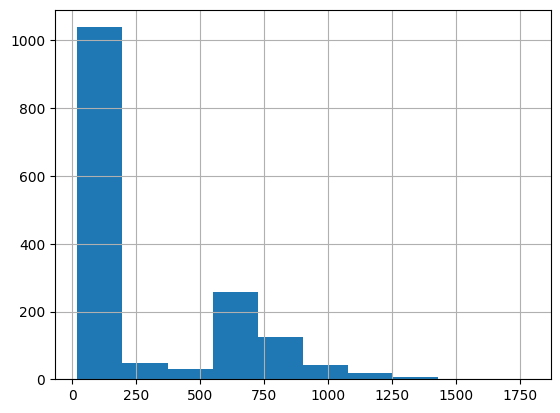

In [47]:
accumulated.query('plan == "surf"')['payment'].hist()

<Axes: ylabel='payment'>

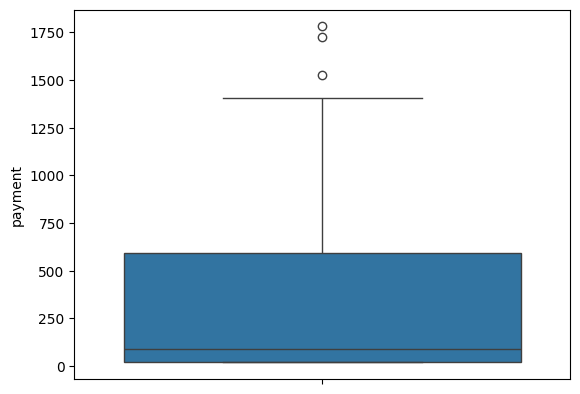

In [48]:
sns.boxplot(accumulated.query('plan == "surf"')['payment'])

<Axes: >

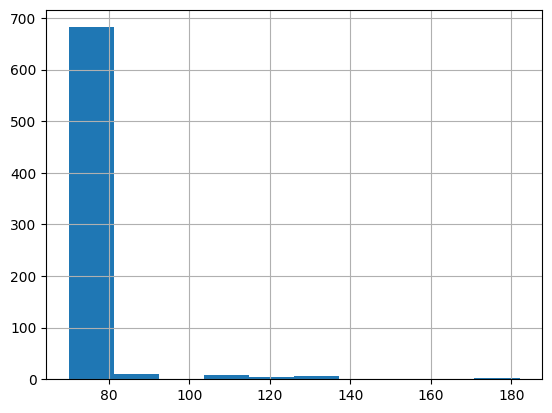

In [49]:
accumulated.query('plan == "ultimate"')['payment'].hist()

<Axes: ylabel='payment'>

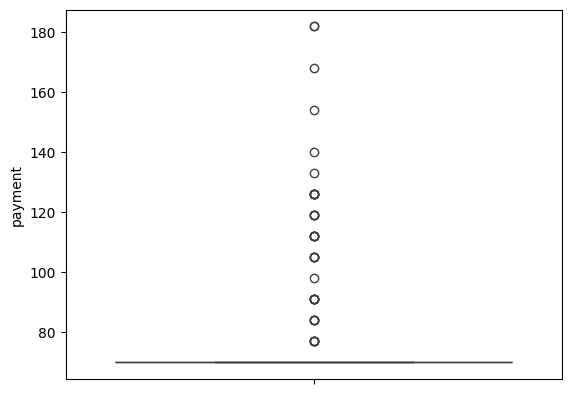

In [50]:
sns.boxplot(accumulated.query('plan == "ultimate"')['payment'])

In [51]:
accumulated['payment'].value_counts()

payment
70.0     718
20.0     453
50.0      55
80.0      51
40.0      50
        ... 
204.5      1
714.5      1
706.0      1
749.0      1
704.0      1
Name: count, Length: 526, dtype: int64

In [52]:
accumulated.groupby('plan')['payment'].sum()

plan
surf        431558.0
ultimate     51926.0
Name: payment, dtype: float64

In [53]:
accumulated.groupby('plan')['payment'].count()

plan
surf        1573
ultimate     718
Name: payment, dtype: int64

In [54]:
accumulated.groupby('plan')['payment'].mean()

plan
surf        274.353465
ultimate     72.320334
Name: payment, dtype: float64

In [55]:
# H0: El promedio mensual de surf y ultimate son iguales
# H1: El promedio mensual de surf es distinto al de ultimate

In [56]:
grupo_surf = accumulated.query('plan == "surf"')['payment']
grupo_ultimate = accumulated.query('plan == "ultimate"')['payment']

In [57]:
result = stats.ttest_ind(grupo_surf, grupo_ultimate)

In [58]:
if result.pvalue < (1 - 0.95):
    print('Rechazamos la hipotesis nula')
else:
    print('No Rechazamos la hipotesis nula')

Rechazamos la hipotesis nula
